# 06 — Sentiment Features (3-Month Horizon)

Add news sentiment as a feature source for the 3-month prediction model.

**Motivation:** Technical indicators are backward-looking — they describe *what happened* but lack information about *market expectations*. News sentiment captures forward-looking information that may improve predictive power.

**Pipeline:** Query GDELT BigQuery (5 years) → extract V2Tone scores → map to S&P 500 tickers → rolling sentiment features → merge with technical features → time-based split → train & compare → save.

**Scope:** 3-month horizon only. The 6m and 1y models stay technical-only per thesis scope.

**Sentiment source:** [GDELT](https://www.gdeltproject.org/) Global Knowledge Graph — monitors worldwide news and computes article-level tone scores. V2Tone provides a dictionary-based sentiment measure covering the full 5-year training period (2021–2026).

**New features (3):**
| Feature | Description |
|---------|-------------|
| `sentiment_avg_20d` | Mean sentiment score over last 20 trading days |
| `sentiment_volume_20d` | Number of news articles in last 20 trading days |
| `sentiment_momentum` | Sentiment trend: avg_20d minus avg_60d |

In [1]:
import os
import json
import re
import time
import warnings
from collections import Counter
from datetime import date, datetime, timedelta

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from google.cloud import bigquery
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

## 1. Configuration & Constants

Paths, feature lists, thresholds, and BigQuery credentials. The service account key is loaded from `data/gcp_key.json`, or falls back to Application Default Credentials.

In [2]:
# ============================================================
# PATHS & CACHING
# ============================================================
CACHE_DIR = os.path.join(".", "data")
os.makedirs(CACHE_DIR, exist_ok=True)

GDELT_CACHE = os.path.join(CACHE_DIR, "gdelt_sentiment_5y.parquet")
OHLCV_CACHE = os.path.join(CACHE_DIR, "sp500_ohlcv_5y.parquet")

MODEL_DIR = os.path.join("..", "src", "ml", "app", "models")
METADATA_PATH = os.path.join(MODEL_DIR, "training_metadata.json")

# ============================================================
# GOOGLE CLOUD — BigQuery authentication
# ============================================================
# Option A: Service account key (if available)
# Option B: Browser-based OAuth via pydata-google-auth (no key needed)
# Option C: gcloud auth application-default login
GCP_KEY_PATH = os.path.join(CACHE_DIR, "gcp_key.json")
GCP_PROJECT = input("Enter your Google Cloud project ID: ")

if os.path.exists(GCP_KEY_PATH):
    BQ_CLIENT = bigquery.Client.from_service_account_json(GCP_KEY_PATH, project=GCP_PROJECT)
    print(f"Authenticated via: service account key")
else:
    try:
        import pydata_google_auth
        credentials = pydata_google_auth.get_user_credentials(
            scopes=["https://www.googleapis.com/auth/bigquery"],
        )
        BQ_CLIENT = bigquery.Client(project=GCP_PROJECT, credentials=credentials)
        print(f"Authenticated via: browser OAuth")
    except ImportError:
        BQ_CLIENT = bigquery.Client(project=GCP_PROJECT)
        print(f"Authenticated via: Application Default Credentials")

print(f"BigQuery project: {GCP_PROJECT}")

# ============================================================
# CONSTANTS
# ============================================================
SIGNAL_LABELS = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]
THRESHOLDS_3M = (-10, -3, 3, 12)
HORIZON_DAYS_3M = 63

TECH_FEATURES = [
    "Price_SMA50_Ratio", "Price_SMA200_Ratio", "Price_EMA20_Ratio",
    "MACD_Norm", "MACD_Signal_Norm", "MACD_Hist_Norm",
    "RSI", "Stoch_K", "Stoch_D", "ROC",
    "BB_Position", "BB_Width", "ATR_Pct",
    "OBV_Norm", "Vol_SMA_Ratio",
    "Dist_52w_High", "Dist_52w_Low", "Return_1m", "Return_3m",
]

SENTIMENT_FEATURES = [
    "sentiment_avg_20d",
    "sentiment_volume_20d",
    "sentiment_momentum",
]

ALL_FEATURES = TECH_FEATURES + SENTIMENT_FEATURES

print(f"\nTechnical features:  {len(TECH_FEATURES)}")
print(f"Sentiment features:  {len(SENTIMENT_FEATURES)}")
print(f"Total features:      {len(ALL_FEATURES)}")

Enter your Google Cloud project ID:  stock-predictor-491310


Authenticated via: browser OAuth
BigQuery project: stock-predictor-491310

Technical features:  19
Sentiment features:  3
Total features:      22


## 2. Load S&P 500 Tickers & Build Company Name Mapping

Use the same 499 tickers from notebook 05 training. Fetch company names from the [S&P 500 Wikipedia table](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies) to match against GDELT organization names.

In [3]:
with open(METADATA_PATH) as f:
    metadata = json.load(f)

tickers = metadata["training_tickers"]
print(f"Loaded {len(tickers)} tickers from training metadata\n")

# ============================================================
# Fetch company names from Wikipedia S&P 500 list
# ============================================================
print("Fetching S&P 500 company names from Wikipedia...")
import requests

resp = requests.get(
    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
    headers={"User-Agent": "StockPredictor/1.0 (academic thesis project)"},
    timeout=15,
)
resp.raise_for_status()
sp500_table = pd.read_html(resp.text)[0]


def clean_company_name(name):
    """Extract core company name for GDELT matching.

    Strips suffixes (Inc, Corp, Corporation, etc.), leading 'The',
    commas, and periods so that Wikipedia names and GDELT org names
    normalize to the same core form.
    """
    name = name.lower().strip()
    name = name.replace(",", " ").replace(".", " ")
    name = re.sub(r"\s+", " ", name).strip()
    # Remove leading "the "
    name = re.sub(r"^the ", "", name)
    # Remove "& co" suffix
    name = re.sub(r"\s*&\s*co\s*$", "", name)
    # Strip corporate suffixes
    name = re.sub(
        r"\s+(inc|corp|co|ltd|llc|plc|lp|nv|sa|corporation|incorporated|"
        r"company|companies|holdings|group|enterprises?|international)\s*$",
        "",
        name,
    )
    return name.strip()


# Map tickers to cleaned company names
ticker_to_company = {}
missing = []

for ticker in tickers:
    row = sp500_table[sp500_table["Symbol"] == ticker]
    if row.empty:
        row = sp500_table[sp500_table["Symbol"] == ticker.replace("-", ".")]
    if not row.empty:
        raw_name = row.iloc[0]["Security"]
        ticker_to_company[ticker] = clean_company_name(raw_name)
    else:
        missing.append(ticker)

# Reverse mapping: company name → [tickers]
company_to_tickers = {}
for ticker, company in ticker_to_company.items():
    company_to_tickers.setdefault(company, []).append(ticker)

# Unique names for GDELT query
company_names = sorted(set(ticker_to_company.values()))

print(f"Mapped {len(ticker_to_company)}/{len(tickers)} tickers to company names")
print(f"Unique company names: {len(company_names)}")
if missing:
    print(f"Not found ({len(missing)}): {missing[:15]}")

print(f"\nSample mapping:")
for t in list(ticker_to_company.keys())[:8]:
    print(f"  {t:5s} → '{ticker_to_company[t]}'")

Loaded 499 tickers from training metadata

Fetching S&P 500 company names from Wikipedia...
Mapped 495/499 tickers to company names
Unique company names: 495
Not found (4): ['LW', 'MOH', 'MTCH', 'PAYC']

Sample mapping:
  A     → 'agilent technologies'
  AAPL  → 'apple'
  ABBV  → 'abbvie'
  ABNB  → 'airbnb'
  ABT   → 'abbott laboratories'
  ACGL  → 'arch capital'
  ACN   → 'accenture'
  ADBE  → 'adobe'


## 3. Fetch Sentiment Data from GDELT BigQuery

Query the [GDELT Global Knowledge Graph](https://www.gdeltproject.org/) via Google BigQuery to get article-level sentiment for all S&P 500 companies.

- **Source:** `gdelt-bq.gdeltv2.gkg_partitioned` — partitioned by date for efficient querying
- **Matching:** UNNEST `V2Organizations` field and match against cleaned S&P 500 company names
- **Sentiment:** `V2Tone` field — overall tone score per article
- **Date range:** March 2021 to present (~60 monthly queries)
- **Cost:** ~150–300 GB scanned total (free tier: 1 TB/month)
- **Caching:** results saved to `gdelt_sentiment_5y.parquet`; re-runs skip the download

In [4]:
def query_gdelt_month(client, year, month, company_names):
    """Query GDELT GKG for articles mentioning our companies in a given month.

    V2Organizations entries have format "Name,CharOffset" (e.g. "Apple Inc,502").
    We extract the name, strip corporate suffixes (Inc, Corp, etc.) to match
    the cleaned company names from Python, then filter via IN UNNEST.
    """
    start = f"{year}-{month:02d}-01"
    if month == 12:
        end = f"{year + 1}-01-01"
    else:
        end = f"{year}-{month + 1:02d}-01"

    query = """
    SELECT
        article_date,
        cleaned_org AS matched_org,
        tone
    FROM (
      SELECT
        SUBSTR(CAST(DATE AS STRING), 1, 8) AS article_date,
        -- 1) Extract org name from "Name,CharOffset" format
        -- 2) Lowercase, replace commas/periods with spaces
        -- 3) Collapse whitespace
        -- 4) Remove leading "the "
        -- 5) Strip corporate suffixes (inc, corp, etc.)
        TRIM(REGEXP_REPLACE(
          REGEXP_REPLACE(
            REGEXP_REPLACE(
              REGEXP_REPLACE(
                LOWER(TRIM(COALESCE(
                  REGEXP_EXTRACT(org_entry, r'^(.+),\\d+$'),
                  org_entry
                ))),
                r'[,.]', ' '
              ),
              r'\\s+', ' '
            ),
            r'^the ', ''
          ),
          r' (inc|corp|co|ltd|llc|plc|lp|nv|sa|corporation|incorporated|company|companies|holdings|group|enterprises?|international)\\s*$',
          ''
        )) AS cleaned_org,
        SAFE_CAST(SPLIT(V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64) AS tone
      FROM `gdelt-bq.gdeltv2.gkg_partitioned`,
      UNNEST(SPLIT(V2Organizations, ';')) AS org_entry
      WHERE _PARTITIONTIME >= TIMESTAMP(@start_date)
        AND _PARTITIONTIME < TIMESTAMP(@end_date)
        AND V2Organizations IS NOT NULL
        AND V2Tone IS NOT NULL
    )
    WHERE cleaned_org IN UNNEST(@names)
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("start_date", "STRING", start),
            bigquery.ScalarQueryParameter("end_date", "STRING", end),
            bigquery.ArrayQueryParameter("names", "STRING", company_names),
        ]
    )

    return client.query(query, job_config=job_config).to_dataframe()


# Generate monthly ranges: March 2021 to current month
months_to_query = []
y, m = 2021, 3
now = datetime.now()
while (y, m) <= (now.year, now.month):
    months_to_query.append((y, m))
    m += 1
    if m > 12:
        m = 1
        y += 1

print(f"Query plan: {len(months_to_query)} months × {len(company_names)} companies")
print(f"Period: {months_to_query[0][0]}-{months_to_query[0][1]:02d} to "
      f"{months_to_query[-1][0]}-{months_to_query[-1][1]:02d}")

Query plan: 61 months × 495 companies
Period: 2021-03 to 2026-03


In [6]:
if os.path.exists(GDELT_CACHE):
    print(f"Loading cached GDELT data from {GDELT_CACHE}...")
    gdelt_df = pd.read_parquet(GDELT_CACHE)
    print(f"Loaded {len(gdelt_df):,} records for {gdelt_df['matched_org'].nunique()} companies")
else:
    print(f"Querying GDELT BigQuery: {len(months_to_query)} months")
    print(f"Estimated data scanned: ~150-300 GB (free tier: 1 TB/month)\n")

    all_results = []
    total_records = 0

    for i, (year, month) in enumerate(months_to_query, 1):
        try:
            df = query_gdelt_month(BQ_CLIENT, year, month, company_names)
            all_results.append(df)
            total_records += len(df)
            print(f"  [{i:2d}/{len(months_to_query)}] {year}-{month:02d}: "
                  f"{len(df):>7,} records | Running total: {total_records:,}")
        except Exception as e:
            print(f"  [{i:2d}/{len(months_to_query)}] {year}-{month:02d}: "
                  f"ERROR — {str(e)[:80]}")

    gdelt_df = pd.concat(all_results, ignore_index=True)
    gdelt_df.to_parquet(GDELT_CACHE, index=False)
    print(f"\nSaved {len(gdelt_df):,} records to {GDELT_CACHE}")

Querying GDELT BigQuery: 61 months
Estimated data scanned: ~150-300 GB (free tier: 1 TB/month)



C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  [ 1/61] 2021-03: 1,017,065 records | Running total: 1,017,065
  [ 2/61] 2021-04: 1,014,014 records | Running total: 2,031,079
  [ 3/61] 2021-05: 1,045,525 records | Running total: 3,076,604
  [ 4/61] 2021-06: 924,639 records | Running total: 4,001,243
  [ 5/61] 2021-07: 902,833 records | Running total: 4,904,076
  [ 6/61] 2021-08: 769,187 records | Running total: 5,673,263
  [ 7/61] 2021-09: 974,146 records | Running total: 6,647,409
  [ 8/61] 2021-10: 1,033,785 records | Running total: 7,681,194
  [ 9/61] 2021-11: 989,558 records | Running total: 8,670,752
  [10/61] 2021-12: 917,370 records | Running total: 9,588,122
  [11/61] 2022-01: 918,051 records | Running total: 10,506,173
  [12/61] 2022-02: 690,765 records | Running total: 11,196,938
  [13/61] 2022-03: 943,619 records | Running total: 12,140,557
  [14/61] 2022-04: 783,720 records | Running total: 12,924,277
  [15/61] 2022-05: 793,736 records | Running total: 13,718,013
  [16/61] 2022-06: 699,763 records | Running total: 14,41

In [7]:
print(f"{'='*50}")
print(f"GDELT Sentiment Summary (5-Year)")
print(f"{'='*50}")
print(f"Total article-company records: {len(gdelt_df):,}")
print(f"Unique companies matched:      {gdelt_df['matched_org'].nunique()}")

# Parse dates for analysis
gdelt_df["date"] = pd.to_datetime(gdelt_df["article_date"], format="%Y%m%d")

print(f"Date range: {gdelt_df['date'].min().date()} to {gdelt_df['date'].max().date()}")

# Per-year breakdown
print(f"\nRecords per year:")
yearly = gdelt_df.groupby(gdelt_df["date"].dt.year).size()
for year, count in yearly.items():
    print(f"  {year}: {count:,}")

# Tone statistics
print(f"\nTone score statistics:")
print(gdelt_df["tone"].describe().to_string())

GDELT Sentiment Summary (5-Year)
Total article-company records: 66,016,919
Unique companies matched:      427
Date range: 2021-03-01 to 2026-03-25

Records per year:
  2021: 9,588,122
  2022: 8,987,437
  2023: 14,305,963
  2024: 17,555,954
  2025: 12,906,666
  2026: 2,672,777

Tone score statistics:
count    6.601692e+07
mean     5.510117e-01
std      2.658816e+00
min     -5.000000e+01
25%     -8.928571e-01
50%      9.671180e-01
75%      1.923077e+00
max      4.000000e+01


## 4. Map to Tickers & Compute Sentiment Score

Map GDELT organization matches back to S&P 500 tickers and normalize the V2Tone score to a $[-1, +1]$ sentiment scale.

**V2Tone normalization:** GDELT tone scores typically range from $-10$ to $+10$. We divide by 10 and clip to $[-1, +1]$ for consistency with standard sentiment scales.

In [8]:
# Build mapping DataFrame: matched_org → ticker
mapping_rows = []
for company, ticker_list in company_to_tickers.items():
    for ticker in ticker_list:
        mapping_rows.append({"matched_org": company, "ticker": ticker})
mapping_df = pd.DataFrame(mapping_rows)

# Merge to get ticker for each record
scored_df = gdelt_df.merge(mapping_df, on="matched_org", how="inner")

# Normalize tone to [-1, +1]
scored_df["sentiment"] = np.clip(scored_df["tone"] / 10, -1, 1)

# Keep only columns needed by downstream pipeline
scored_df = scored_df[["ticker", "date", "sentiment"]].copy()

print(f"Scored records:          {len(scored_df):,}")
print(f"Tickers with sentiment:  {scored_df['ticker'].nunique()}")
print(f"Date range:              {scored_df['date'].min().date()} to {scored_df['date'].max().date()}")
print(f"Avg records per ticker:  {len(scored_df) / scored_df['ticker'].nunique():.0f}")

print(f"\nSentiment score statistics:")
print(scored_df["sentiment"].describe().to_string())

Scored records:          66,016,919
Tickers with sentiment:  427
Date range:              2021-03-01 to 2026-03-25
Avg records per ticker:  154606

Sentiment score statistics:
count    6.601692e+07
mean     5.511215e-02
std      2.638285e-01
min     -1.000000e+00
25%     -8.928571e-02
50%      9.671180e-02
75%      1.923077e-01
max      1.000000e+00


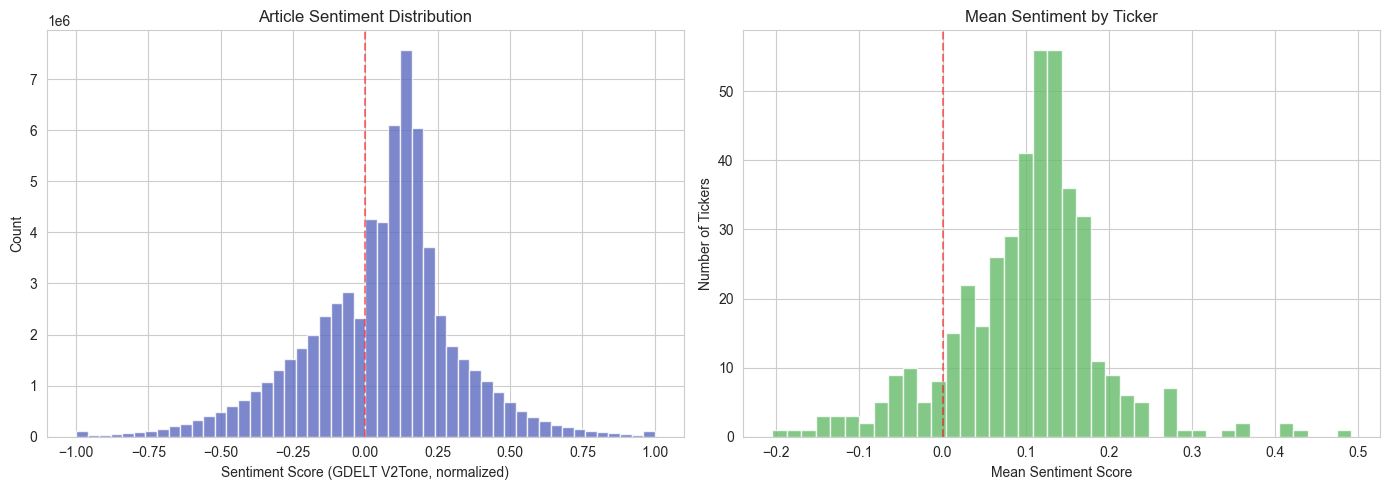


Sentiment Score Statistics:
count    6.601692e+07
mean     5.511215e-02
std      2.638285e-01
min     -1.000000e+00
25%     -8.928571e-02
50%      9.671180e-02
75%      1.923077e-01
max      1.000000e+00

Most positive tickers:  {'LYB': 0.49180327868852497, 'ESS': 0.42912975494488487, 'CPT': 0.40933931980232213, 'ELV': 0.40848270301219913, 'CCI': 0.35974935139287895}
Most negative tickers:  {'NSC': -0.20483310534949495, 'XYZ': -0.18692142638244788, 'CVNA': -0.15860410476322082, 'GWW': -0.1524839935481513, 'LUV': -0.1519464608387203}


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of individual article scores
axes[0].hist(scored_df["sentiment"], bins=50, color="#5c6bc0", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Sentiment Score (GDELT V2Tone, normalized)")
axes[0].set_ylabel("Count")
axes[0].set_title("Article Sentiment Distribution")

# Average sentiment per ticker
ticker_avg = scored_df.groupby("ticker")["sentiment"].mean()
axes[1].hist(ticker_avg, bins=40, color="#66bb6a", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Mean Sentiment Score")
axes[1].set_ylabel("Number of Tickers")
axes[1].set_title("Mean Sentiment by Ticker")

plt.tight_layout()
plt.show()

print(f"\nSentiment Score Statistics:")
print(scored_df["sentiment"].describe().to_string())
print(f"\nMost positive tickers:  {ticker_avg.nlargest(5).to_dict()}")
print(f"Most negative tickers:  {ticker_avg.nsmallest(5).to_dict()}")

## 5. Load Stock Data & Compute Technical Features

Re-download 5 years of OHLCV data for all tickers (cached to parquet for re-runs), then compute the same 19 technical features from notebooks 02–05.

This is needed to:
1. Get trading dates for aligning sentiment features
2. Build the combined 3m dataset with all 22 features

In [10]:
def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute all technical indicators on a DataFrame with OHLCV columns.

    All features are relative (ratios, percentages, bounded scales) so they
    generalize across stocks at different price levels.
    """
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # --- Trend (ratios around 1.0) ---
    sma_50 = df["Close"].rolling(window=50).mean()
    sma_200 = df["Close"].rolling(window=200).mean()
    ema_20 = df["Close"].ewm(span=20, adjust=False).mean()
    df["Price_SMA50_Ratio"] = df["Close"] / sma_50
    df["Price_SMA200_Ratio"] = df["Close"] / sma_200
    df["Price_EMA20_Ratio"] = df["Close"] / ema_20

    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
    macd_raw = ema_12 - ema_26
    macd_signal_raw = macd_raw.ewm(span=9, adjust=False).mean()
    df["MACD_Norm"] = macd_raw / df["Close"] * 100
    df["MACD_Signal_Norm"] = macd_signal_raw / df["Close"] * 100
    df["MACD_Hist_Norm"] = df["MACD_Norm"] - df["MACD_Signal_Norm"]

    # --- Momentum ---
    delta = df["Close"].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    rs = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + rs))

    low_14 = df["Low"].rolling(window=14).min()
    high_14 = df["High"].rolling(window=14).max()
    df["Stoch_K"] = 100 * (df["Close"] - low_14) / (high_14 - low_14)
    df["Stoch_D"] = df["Stoch_K"].rolling(window=3).mean()
    df["ROC"] = df["Close"].pct_change(periods=21) * 100

    # --- Volatility (relative) ---
    bb_sma = df["Close"].rolling(window=20).mean()
    bb_std = df["Close"].rolling(window=20).std()
    bb_upper = bb_sma + 2 * bb_std
    bb_lower = bb_sma - 2 * bb_std
    df["BB_Position"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower)
    df["BB_Width"] = (bb_upper - bb_lower) / bb_sma

    high_low = df["High"] - df["Low"]
    high_close = (df["High"] - df["Close"].shift(1)).abs()
    low_close = (df["Low"] - df["Close"].shift(1)).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df["ATR_Pct"] = true_range.rolling(window=14).mean() / df["Close"] * 100

    # --- Volume (relative) ---
    obv_sign = np.sign(df["Close"].diff())
    obv = (obv_sign * df["Volume"]).cumsum()
    df["OBV_Norm"] = obv.diff(21) / df["Volume"].rolling(21).mean()
    df["Vol_SMA_Ratio"] = df["Volume"] / df["Volume"].rolling(window=20).mean()

    # --- Price-derived (percentages) ---
    high_252 = df["High"].rolling(window=252).max()
    low_252 = df["Low"].rolling(window=252).min()
    df["Dist_52w_High"] = (df["Close"] - high_252) / high_252 * 100
    df["Dist_52w_Low"] = (df["Close"] - low_252) / low_252 * 100
    df["Return_1m"] = df["Close"].pct_change(periods=21) * 100
    df["Return_3m"] = df["Close"].pct_change(periods=63) * 100

    return df


def compute_future_returns(close: pd.Series, horizon_days: int) -> pd.Series:
    """Compute percentage return over the next horizon_days."""
    return (close.shift(-horizon_days) / close - 1) * 100


def assign_signal(returns: pd.Series, thresholds: tuple) -> pd.Series:
    """Assign trading signal based on future return thresholds."""
    ss, s, b, sb = thresholds
    conditions = [
        returns < ss,
        (returns >= ss) & (returns < s),
        (returns >= s) & (returns < b),
        (returns >= b) & (returns < sb),
        returns >= sb,
    ]
    return pd.Series(
        np.select(conditions, SIGNAL_LABELS, default=""),
        index=returns.index,
    ).replace("", np.nan)


print(f"Functions loaded. {len(TECH_FEATURES)} technical features defined.")

Functions loaded. 19 technical features defined.


In [11]:
if os.path.exists(OHLCV_CACHE):
    print(f"Loading cached OHLCV data from {OHLCV_CACHE}...")
    ohlcv_all = pd.read_parquet(OHLCV_CACHE)
    all_data = {}
    for ticker in ohlcv_all["Ticker"].unique():
        df = ohlcv_all[ohlcv_all["Ticker"] == ticker].drop(columns=["Ticker"])
        df.index = pd.to_datetime(df.index)
        all_data[ticker] = df
    print(f"Loaded {len(all_data)} tickers")
else:
    BATCH_SIZE = 50
    MIN_ROWS = 504

    batches = [tickers[i:i + BATCH_SIZE] for i in range(0, len(tickers), BATCH_SIZE)]
    n_batches = len(batches)

    all_data = {}
    failed_tickers = []

    print(f"Downloading {len(tickers)} tickers in {n_batches} batches of {BATCH_SIZE}...\n")

    for batch_num, batch in enumerate(batches, 1):
        print(f"Batch {batch_num}/{n_batches}: downloading {len(batch)} tickers...")
        try:
            raw = yf.download(batch, period="5y", group_by="ticker", auto_adjust=True)
            for ticker in batch:
                try:
                    df = raw[ticker].copy()
                    df = df.dropna(how="all")
                    if len(df) < MIN_ROWS:
                        failed_tickers.append((ticker, f"insufficient data: {len(df)} rows"))
                        continue
                    all_data[ticker] = df
                except KeyError:
                    failed_tickers.append((ticker, "not found in download"))
                except Exception as e:
                    failed_tickers.append((ticker, str(e)[:80]))
        except Exception as e:
            print(f"  Batch {batch_num} failed: {e}")
            for t in batch:
                failed_tickers.append((t, f"batch error: {str(e)[:50]}"))
        if batch_num < n_batches:
            time.sleep(2)

    print(f"\nDownload complete: {len(all_data)} succeeded, {len(failed_tickers)} failed")
    if failed_tickers:
        print(f"Failed: {[t for t, _ in failed_tickers[:10]]}")

    # Cache to parquet
    frames = []
    for ticker, df in all_data.items():
        temp = df.copy()
        temp["Ticker"] = ticker
        frames.append(temp)
    ohlcv_all = pd.concat(frames)
    ohlcv_all.to_parquet(OHLCV_CACHE)
    print(f"Saved OHLCV cache to {OHLCV_CACHE}")

Loading cached OHLCV data from .\data\sp500_ohlcv_5y.parquet...
Loaded 499 tickers


In [12]:
print(f"Computing features for {len(all_data)} tickers...\n")

processed = {}
feature_errors = []

for i, (ticker, df) in enumerate(all_data.items(), 1):
    try:
        processed[ticker] = compute_features(df)
    except Exception as e:
        feature_errors.append((ticker, str(e)[:80]))
    if i % 100 == 0 or i == len(all_data):
        print(f"  Progress: {i}/{len(all_data)} tickers processed")

print(f"\nFeatures computed: {len(processed)} succeeded, {len(feature_errors)} failed")
if feature_errors:
    print(f"Feature errors: {feature_errors[:5]}")

# Free raw data
del all_data

Computing features for 499 tickers...

  Progress: 100/499 tickers processed
  Progress: 200/499 tickers processed
  Progress: 300/499 tickers processed
  Progress: 400/499 tickers processed
  Progress: 499/499 tickers processed

Features computed: 499 succeeded, 0 failed


## 6. Compute Rolling Sentiment Features

For each stock, align article sentiment to trading dates, then compute rolling features:

| Feature | Computation | Window |
|---------|-------------|--------|
| `sentiment_avg_20d` | Rolling mean of daily sentiment | 20 trading days |
| `sentiment_volume_20d` | Rolling sum of article counts | 20 trading days |
| `sentiment_momentum` | `avg_20d - avg_60d` (sentiment trend) | 20d vs 60d |

**Alignment:** Articles are mapped to trading days. Days with no news carry forward the last known sentiment (forward-fill). With 5 years of GDELT data, most trading days should have nearby articles, giving strong coverage across the full training period. XGBoost handles any remaining NaN values natively.

In [13]:
def compute_sentiment_features(scored_df, processed):
    """Compute rolling sentiment features aligned to each stock's trading dates.

    Parameters
    ----------
    scored_df : DataFrame with columns [ticker, date, sentiment]
    processed : dict of {ticker: DataFrame with DatetimeIndex}

    Returns
    -------
    DataFrame with columns [ticker, date, sentiment_avg_20d, sentiment_volume_20d, sentiment_momentum]
    """
    all_features = []
    tickers_with_news = scored_df["ticker"].unique()
    n_tickers = len(tickers_with_news)

    for i, ticker in enumerate(tickers_with_news, 1):
        if ticker not in processed:
            continue

        # Get this ticker's headlines
        ticker_news = scored_df[scored_df["ticker"] == ticker].copy()

        # Aggregate by date: mean sentiment and article count
        daily = ticker_news.groupby("date").agg(
            daily_sentiment=("sentiment", "mean"),
            daily_count=("sentiment", "count"),
        )

        # Get trading dates for this ticker
        trading_dates = processed[ticker].index

        # Reindex to trading dates
        daily_aligned = daily.reindex(trading_dates)

        # Forward-fill sentiment (carry last known value)
        daily_aligned["daily_sentiment"] = daily_aligned["daily_sentiment"].ffill()
        # No-news days get count = 0
        daily_aligned["daily_count"] = daily_aligned["daily_count"].fillna(0)

        # Compute rolling features
        sent_avg_20 = daily_aligned["daily_sentiment"].rolling(20, min_periods=5).mean()
        sent_avg_60 = daily_aligned["daily_sentiment"].rolling(60, min_periods=10).mean()
        sent_vol_20 = daily_aligned["daily_count"].rolling(20, min_periods=1).sum()

        feat_df = pd.DataFrame({
            "ticker": ticker,
            "date": trading_dates,
            "sentiment_avg_20d": sent_avg_20.values,
            "sentiment_volume_20d": sent_vol_20.values,
            "sentiment_momentum": (sent_avg_20 - sent_avg_60).values,
        })

        all_features.append(feat_df)

        if i % 100 == 0 or i == n_tickers:
            print(f"  [{i}/{n_tickers}] tickers processed")

    return pd.concat(all_features, ignore_index=True)


print("Computing rolling sentiment features...\n")
sentiment_features = compute_sentiment_features(scored_df, processed)
print(f"\nResult: {len(sentiment_features):,} rows for {sentiment_features['ticker'].nunique()} tickers")

Computing rolling sentiment features...

  [100/427] tickers processed
  [200/427] tickers processed
  [300/427] tickers processed
  [400/427] tickers processed
  [427/427] tickers processed

Result: 533,960 rows for 427 tickers


In [14]:
# How many rows have non-NaN sentiment?
has_sentiment = sentiment_features["sentiment_avg_20d"].notna()
print(f"{'='*50}")
print(f"Sentiment Feature Coverage")
print(f"{'='*50}")
print(f"Total rows:          {len(sentiment_features):,}")
print(f"With sentiment:      {has_sentiment.sum():,} ({has_sentiment.mean()*100:.1f}%)")
print(f"Without (NaN):       {(~has_sentiment).sum():,} ({(~has_sentiment).mean()*100:.1f}%)")

# Date range with sentiment
sent_rows = sentiment_features[has_sentiment]
print(f"\nSentiment date range: {sent_rows['date'].min().date()} to {sent_rows['date'].max().date()}")

# Feature distributions (non-NaN only)
print(f"\nFeature statistics (non-NaN rows):")
for feat in SENTIMENT_FEATURES:
    vals = sentiment_features[feat].dropna()
    print(f"  {feat}:")
    print(f"    mean={vals.mean():.4f}  std={vals.std():.4f}  min={vals.min():.4f}  max={vals.max():.4f}")

Sentiment Feature Coverage
Total rows:          533,960
With sentiment:      520,535 (97.5%)
Without (NaN):       13,425 (2.5%)

Sentiment date range: 2021-03-31 to 2026-03-24

Feature statistics (non-NaN rows):
  sentiment_avg_20d:
    mean=0.1018  std=0.1245  min=-1.0000  max=1.0000
  sentiment_volume_20d:
    mean=1960.7698  std=8931.7460  min=0.0000  max=266793.0000
  sentiment_momentum:
    mean=0.0004  std=0.0662  min=-0.6652  max=0.7813


## 7. Build Combined 3m Dataset

Merge the 19 technical features with the 3 sentiment features for the 3-month horizon.

- Compute future returns and assign signals using the adjusted thresholds
- Merge sentiment features by (ticker, date)
- With 5 years of news, most rows should have real sentiment values
- Any remaining NaN values are handled natively by XGBoost

In [15]:
# Build 3m labeled dataset (same as notebook 05)
datasets = []

for ticker, df in processed.items():
    future_ret = compute_future_returns(df["Close"], HORIZON_DAYS_3M)
    signals = assign_signal(future_ret, THRESHOLDS_3M)
    subset = df[TECH_FEATURES].copy()
    subset["Signal"] = signals
    subset["Ticker"] = ticker
    subset = subset.dropna(subset=TECH_FEATURES + ["Signal"])
    if len(subset) > 0:
        datasets.append(subset)

df_3m = pd.concat(datasets)
print(f"3m dataset: {len(df_3m):,} samples from {df_3m['Ticker'].nunique()} tickers")
print(f"Date range: {df_3m.index.min().date()} to {df_3m.index.max().date()}")

# Merge sentiment features
sentiment_features["date"] = pd.to_datetime(sentiment_features["date"])
df_3m = df_3m.reset_index()
df_3m = df_3m.rename(columns={"Date": "date", "index": "date"} if "index" in df_3m.columns else {"Date": "date"})
if "date" not in df_3m.columns:
    df_3m = df_3m.rename(columns={df_3m.columns[0]: "date"})
df_3m["date"] = pd.to_datetime(df_3m["date"])

df_3m = df_3m.merge(
    sentiment_features[["ticker", "date"] + SENTIMENT_FEATURES],
    left_on=["Ticker", "date"],
    right_on=["ticker", "date"],
    how="left",
).drop(columns=["ticker"], errors="ignore")

df_3m = df_3m.set_index("date")

print(f"\nAfter merge: {len(df_3m):,} samples")

# Sentiment coverage in final dataset
has_sent = df_3m["sentiment_avg_20d"].notna()
print(f"With sentiment:    {has_sent.sum():,} ({has_sent.mean()*100:.1f}%)")
print(f"Without sentiment: {(~has_sent).sum():,} ({(~has_sent).mean()*100:.1f}%)")

# Class distribution check
print(f"\nClass distribution:")
counts = df_3m["Signal"].value_counts().reindex(SIGNAL_LABELS)
pcts = counts / counts.sum() * 100
for label, count, pct in zip(SIGNAL_LABELS, counts, pcts):
    ok = "ok" if 12 <= pct <= 30 else "!!"
    print(f"  {label:>12}: {int(count):6,} ({pct:5.1f}%) [{ok}]")

3m dataset: 467,631 samples from 499 tickers
Date range: 2022-03-23 to 2025-12-19

After merge: 467,631 samples
With sentiment:    394,255 (84.3%)
Without sentiment: 73,376 (15.7%)

Class distribution:
   Strong Sell: 77,271 ( 16.5%) [ok]
          Sell: 77,464 ( 16.6%) [ok]
          Hold: 82,560 ( 17.7%) [ok]
           Buy: 112,164 ( 24.0%) [ok]
    Strong Buy: 118,172 ( 25.3%) [ok]


## 8. Time-Based Split

Split at **September 2025** for chronological evaluation — the model trains on historical data and is tested on the most recent period, matching how it would be used in production.

- **Training:** ~2021 to August 2025
- **Test:** September 2025 to ~December 2025
- Both periods have sentiment coverage (5 years of news data)

In [16]:
SPLIT_DATE = pd.Timestamp("2025-09-01")

le = LabelEncoder()
le.fit(SIGNAL_LABELS)

train = df_3m[df_3m.index < SPLIT_DATE]
test = df_3m[df_3m.index >= SPLIT_DATE]

# Encode labels
y_train = le.transform(train["Signal"])
y_test = le.transform(test["Signal"])

# Verify no data leakage
assert test.index.min() > train.index.max(), "Data leakage detected!"

print(f"{'='*50}")
print(f"3m Horizon — Sentiment-Aware Split")
print(f"{'='*50}")
print(f"Split date: {SPLIT_DATE.date()}")
print(f"Train: {len(train):,} samples ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {len(test):,} samples ({test.index.min().date()} to {test.index.max().date()})")
print(f"No leakage: verified\n")

# Sentiment coverage in train vs test
train_sent = train["sentiment_avg_20d"].notna().mean() * 100
test_sent = test["sentiment_avg_20d"].notna().mean() * 100
print(f"Sentiment coverage:")
print(f"  Train: {train_sent:.1f}% of rows have sentiment")
print(f"  Test:  {test_sent:.1f}% of rows have sentiment")

# Class distribution in train vs test
print(f"\n  {'':>12} {'Train':>8} {'Test':>8}")
print(f"  {'-'*30}")
for i, label in enumerate(SIGNAL_LABELS):
    tr_pct = (y_train == i).sum() / len(y_train) * 100
    te_pct = (y_test == i).sum() / len(y_test) * 100
    print(f"  {label:>12} {tr_pct:7.1f}% {te_pct:7.1f}%")

3m Horizon — Sentiment-Aware Split
Split date: 2025-09-01
Train: 428,713 samples (2022-03-23 to 2025-08-29)
Test:  38,918 samples (2025-09-02 to 2025-12-19)
No leakage: verified

Sentiment coverage:
  Train: 84.2% of rows have sentiment
  Test:  85.2% of rows have sentiment

                  Train     Test
  ------------------------------
   Strong Sell    24.2%    21.6%
          Sell    17.8%    16.4%
          Hold    16.6%    15.6%
           Buy    24.9%    28.9%
    Strong Buy    16.4%    17.4%


## 9. Train XGBoost — Technical vs. Sentiment

Train **two models** on the same train/test split for a fair comparison:

- **Model A (baseline):** 19 technical features only — same features as notebook 05, but on the new sentiment-aware split
- **Model B (sentiment):** 22 features — 19 technical + 3 sentiment

Both use the same hyperparameters: `n_estimators=200, max_depth=6, learning_rate=0.1`, with class weights via `sample_weight`.

In [17]:
# Compute class weights
class_counts = Counter(y_train)
total = len(y_train)
n_classes = len(SIGNAL_LABELS)
class_weights = {cls: total / (n_classes * count) for cls, count in class_counts.items()}
sample_weights = np.array([class_weights[y] for y in y_train])

weights_str = ", ".join(f"{SIGNAL_LABELS[k]}={v:.2f}" for k, v in sorted(class_weights.items()))
print(f"Class weights: {weights_str}\n")

# ============================================================
# MODEL A: Technical features only (19 features)
# ============================================================
print(f"{'='*50}")
print(f"Training Model A — Technical Only (19 features)")
print(f"{'='*50}")

X_train_tech = train[TECH_FEATURES]
X_test_tech = test[TECH_FEATURES]

model_a = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)
model_a.fit(X_train_tech, y_train, sample_weight=sample_weights)
print(f"Model A trained: {len(X_train_tech):,} samples, {len(TECH_FEATURES)} features\n")

# ============================================================
# MODEL B: Technical + Sentiment (22 features)
# ============================================================
print(f"{'='*50}")
print(f"Training Model B — Technical + Sentiment (22 features)")
print(f"{'='*50}")

X_train_all = train[ALL_FEATURES]
X_test_all = test[ALL_FEATURES]

model_b = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)
model_b.fit(X_train_all, y_train, sample_weight=sample_weights)
print(f"Model B trained: {len(X_train_all):,} samples, {len(ALL_FEATURES)} features")
print(f"  NaN sentiment in training: {X_train_all[SENTIMENT_FEATURES].isna().any(axis=1).sum():,} rows")

Class weights: Strong Sell=0.83, Sell=1.13, Hold=1.20, Buy=0.80, Strong Buy=1.22

Training Model A — Technical Only (19 features)
Model A trained: 428,713 samples, 19 features

Training Model B — Technical + Sentiment (22 features)
Model B trained: 428,713 samples, 22 features
  NaN sentiment in training: 67,664 rows


## 10. Evaluate & Compare

The key thesis result: does adding sentiment features improve prediction quality?

Metrics:
- **Weighted F1** (primary) — balances precision and recall across classes
- **Accuracy** — raw correct predictions
- **MAE on class index** — penalizes distant misclassifications (0=perfect, 4=worst)

In [18]:
# Evaluate Model A
y_pred_a = model_a.predict(X_test_tech)
f1_a = f1_score(y_test, y_pred_a, average="weighted")
acc_a = accuracy_score(y_test, y_pred_a)
mae_a = mean_absolute_error(y_test, y_pred_a)

print(f"{'='*50}")
print(f"Model A — Technical Only (19 features)")
print(f"{'='*50}")
print(f"Weighted F1:  {f1_a:.4f}")
print(f"Accuracy:     {acc_a:.4f}")
print(f"MAE (class):  {mae_a:.4f}")
print(f"\n{classification_report(y_test, y_pred_a, target_names=SIGNAL_LABELS, zero_division=0)}")

# Evaluate Model B
y_pred_b = model_b.predict(X_test_all)
f1_b = f1_score(y_test, y_pred_b, average="weighted")
acc_b = accuracy_score(y_test, y_pred_b)
mae_b = mean_absolute_error(y_test, y_pred_b)

print(f"{'='*50}")
print(f"Model B — Technical + Sentiment (22 features)")
print(f"{'='*50}")
print(f"Weighted F1:  {f1_b:.4f}")
print(f"Accuracy:     {acc_b:.4f}")
print(f"MAE (class):  {mae_b:.4f}")
print(f"\n{classification_report(y_test, y_pred_b, target_names=SIGNAL_LABELS, zero_division=0)}")

Model A — Technical Only (19 features)
Weighted F1:  0.2502
Accuracy:     0.2508
MAE (class):  1.3860

              precision    recall  f1-score   support

 Strong Sell       0.27      0.20      0.23      8415
        Sell       0.21      0.25      0.23      6391
        Hold       0.18      0.16      0.17      6087
         Buy       0.33      0.30      0.31     11254
  Strong Buy       0.22      0.32      0.26      6771

    accuracy                           0.25     38918
   macro avg       0.24      0.25      0.24     38918
weighted avg       0.26      0.25      0.25     38918

Model B — Technical + Sentiment (22 features)
Weighted F1:  0.2612
Accuracy:     0.2613
MAE (class):  1.3651

              precision    recall  f1-score   support

 Strong Sell       0.27      0.21      0.23      8415
        Sell       0.23      0.24      0.24      6391
        Hold       0.19      0.20      0.19      6087
         Buy       0.34      0.32      0.33     11254
  Strong Buy       0.23    

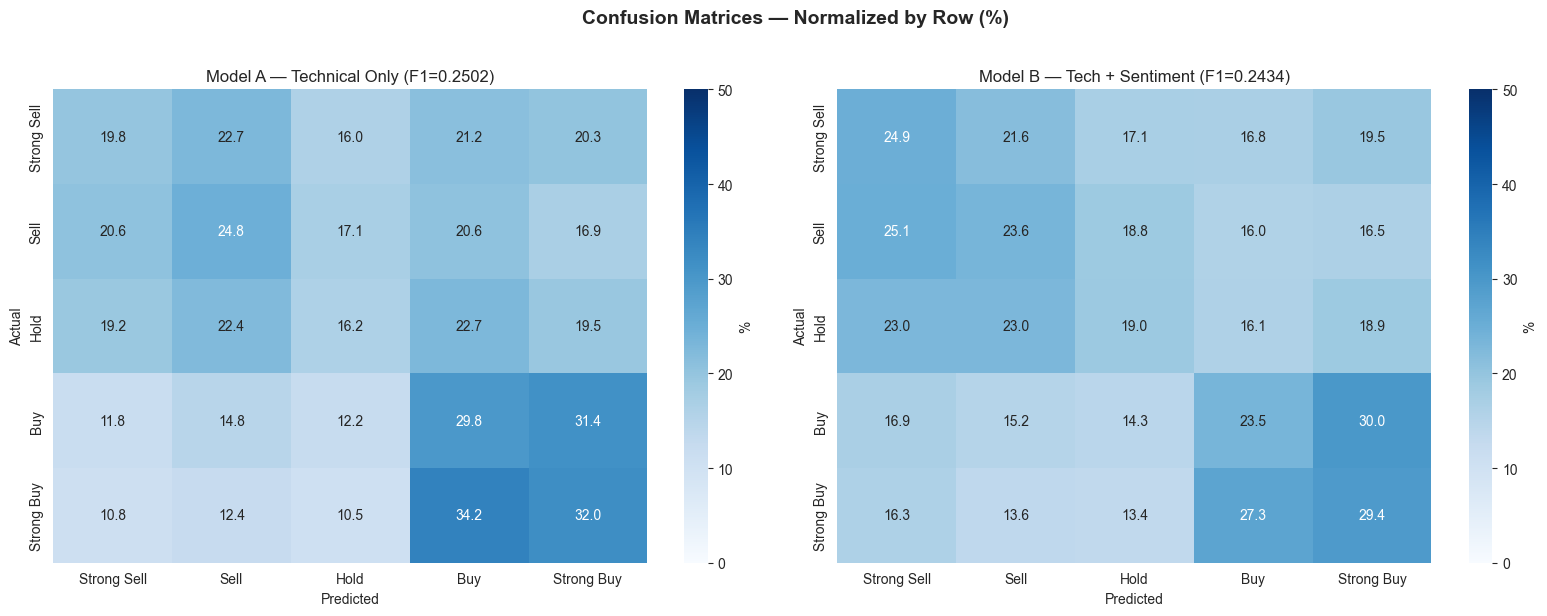

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in [
    (axes[0], y_pred_a, f"Model A — Technical Only (F1={f1_a:.4f})"),
    (axes[1], y_pred_b, f"Model B — Tech + Sentiment (F1={f1_b:.4f})"),
]:
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt=".1f", cmap="Blues",
        xticklabels=SIGNAL_LABELS, yticklabels=SIGNAL_LABELS,
        ax=ax, vmin=0, vmax=50, cbar_kws={"label": "%"},
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.suptitle("Confusion Matrices — Normalized by Row (%)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

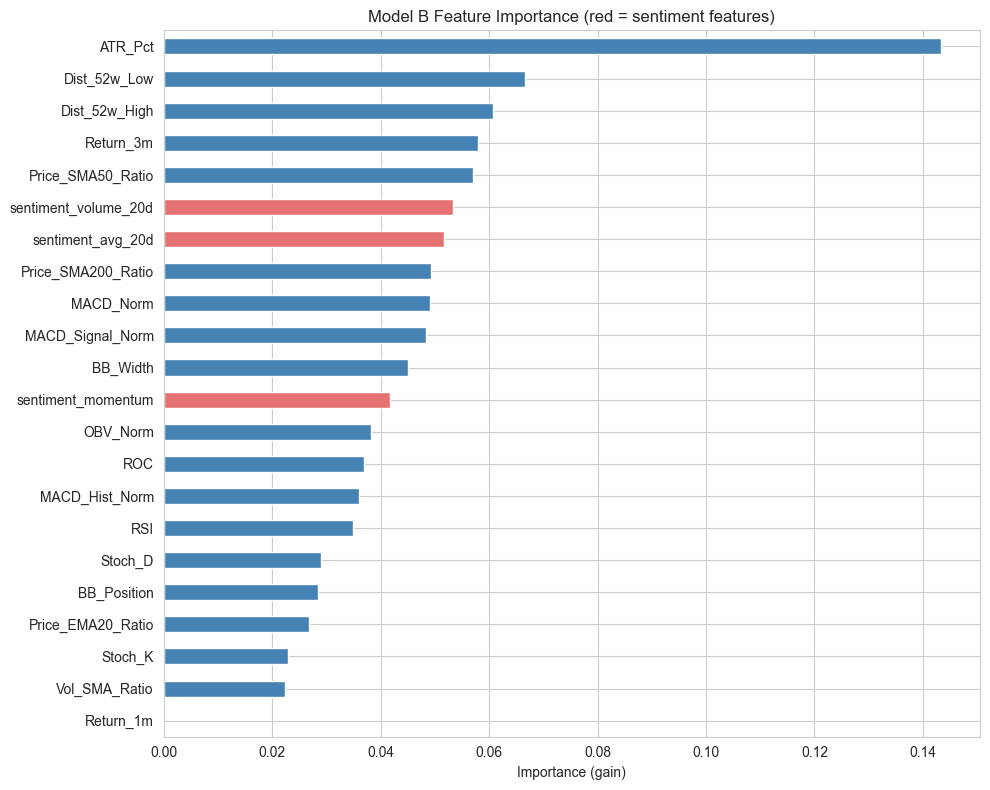


Sentiment feature rankings (out of 22):
  # 7 sentiment_avg_20d: 0.0516
  # 6 sentiment_volume_20d: 0.0533
  #12 sentiment_momentum: 0.0418


In [19]:
# Feature importance for Model B — where do sentiment features rank?
importances = pd.Series(
    model_b.feature_importances_, index=ALL_FEATURES
).sort_values(ascending=True)

# Color sentiment features differently
colors = ["#e57373" if feat in SENTIMENT_FEATURES else "steelblue" for feat in importances.index]

fig, ax = plt.subplots(figsize=(10, 8))
importances.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Importance (gain)")
ax.set_title("Model B Feature Importance (red = sentiment features)")
plt.tight_layout()
plt.show()

# Sentiment feature ranks
print(f"\nSentiment feature rankings (out of {len(ALL_FEATURES)}):")
ranked = importances.sort_values(ascending=False)
for feat in SENTIMENT_FEATURES:
    rank = list(ranked.index).index(feat) + 1
    imp = ranked[feat]
    print(f"  #{rank:2d} {feat}: {imp:.4f}")

In [20]:
# ============================================================
# SIDE-BY-SIDE COMPARISON TABLE
# ============================================================
comparison = pd.DataFrame({
    "Model A (Technical)": {
        "Features": len(TECH_FEATURES),
        "Weighted F1": f"{f1_a:.4f}",
        "Accuracy": f"{acc_a:.4f}",
        "MAE (class)": f"{mae_a:.4f}",
        "Train samples": f"{len(X_train_tech):,}",
        "Test samples": f"{len(X_test_tech):,}",
    },
    "Model B (Tech + Sentiment)": {
        "Features": len(ALL_FEATURES),
        "Weighted F1": f"{f1_b:.4f}",
        "Accuracy": f"{acc_b:.4f}",
        "MAE (class)": f"{mae_b:.4f}",
        "Train samples": f"{len(X_train_all):,}",
        "Test samples": f"{len(X_test_all):,}",
    },
})

# Add delta column
comparison["Delta"] = ""
comparison.loc["Weighted F1", "Delta"] = f"{f1_b - f1_a:+.4f}"
comparison.loc["Accuracy", "Delta"] = f"{acc_b - acc_a:+.4f}"
comparison.loc["MAE (class)", "Delta"] = f"{mae_b - mae_a:+.4f}"

print(f"{'='*60}")
print(f"  COMPARISON: Technical vs. Technical + Sentiment (3m Horizon)")
print(f"{'='*60}")
print(comparison.to_string())

# Verdict
f1_diff = f1_b - f1_a
if f1_diff > 0.005:
    verdict = f"Sentiment IMPROVED F1 by {f1_diff:+.4f}"
elif f1_diff < -0.005:
    verdict = f"Sentiment HURT F1 by {f1_diff:+.4f}"
else:
    verdict = f"Sentiment had NEGLIGIBLE effect ({f1_diff:+.4f})"

print(f"\n>>> {verdict}")
print(f"\nNotebook 05 baseline (different split): Weighted F1 = {metadata['results']['3m']['weighted_f1']:.4f}")

  COMPARISON: Technical vs. Technical + Sentiment (3m Horizon)
              Model A (Technical) Model B (Tech + Sentiment)    Delta
Features                       19                         22         
Weighted F1                0.2502                     0.2612  +0.0111
Accuracy                   0.2508                     0.2613  +0.0105
MAE (class)                1.3860                     1.3651  -0.0209
Train samples             428,713                    428,713         
Test samples               38,918                     38,918         

>>> Sentiment IMPROVED F1 by +0.0111

Notebook 05 baseline (different split): Weighted F1 = 0.2632


## 11. Save Updated Model

If Model B (with sentiment) improves on Model A, save it as `xgb_3m_sentiment.joblib`. The original `xgb_3m.joblib` stays as the technical-only baseline.

Update `training_metadata.json` with the new feature list and results.

In [21]:
save_dir = MODEL_DIR
os.makedirs(save_dir, exist_ok=True)

# Always save the sentiment model for comparison purposes
path_b = os.path.join(save_dir, "xgb_3m_sentiment.joblib")
joblib.dump(model_b, path_b)
print(f"Saved: {path_b}")

# Save label encoder (same as before)
joblib.dump(le, os.path.join(save_dir, "label_encoder.joblib"))
print(f"Saved: {os.path.join(save_dir, 'label_encoder.joblib')}")

# Update training metadata
metadata["sentiment_model"] = {
    "horizon": "3m",
    "feature_columns": ALL_FEATURES,
    "n_features": len(ALL_FEATURES),
    "sentiment_features": SENTIMENT_FEATURES,
    "split_date": str(SPLIT_DATE.date()),
    "results": {
        "model_a_technical": {
            "weighted_f1": round(f1_a, 4),
            "accuracy": round(acc_a, 4),
            "mae": round(mae_a, 4),
            "n_features": len(TECH_FEATURES),
            "train_samples": len(X_train_tech),
            "test_samples": len(X_test_tech),
        },
        "model_b_sentiment": {
            "weighted_f1": round(f1_b, 4),
            "accuracy": round(acc_b, 4),
            "mae": round(mae_b, 4),
            "n_features": len(ALL_FEATURES),
            "train_samples": len(X_train_all),
            "test_samples": len(X_test_all),
        },
    },
}

with open(os.path.join(save_dir, "training_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved: {os.path.join(save_dir, 'training_metadata.json')}")

f1_diff = f1_b - f1_a
if f1_diff > 0.005:
    print(f"\nModel B saved as xgb_3m_sentiment.joblib (F1 improved by {f1_diff:+.4f})")
    print("Consider using this model for 3m predictions in the API.")
else:
    print(f"\nModel B saved for reference but did NOT significantly improve F1 ({f1_diff:+.4f}).")
    print("The original xgb_3m.joblib remains the recommended 3m model.")

print(f"\nAll artifacts saved to {save_dir}/")

Saved: ..\src\ml\app\models\xgb_3m_sentiment.joblib
Saved: ..\src\ml\app\models\label_encoder.joblib
Saved: ..\src\ml\app\models\training_metadata.json

Model B saved as xgb_3m_sentiment.joblib (F1 improved by +0.0111)
Consider using this model for 3m predictions in the API.

All artifacts saved to ..\src\ml\app\models/
